# Evaluation

- Evaluate training and test data distributions
- Display feature importances
- Inspect SHAP results

In [1]:
import xgboost as xgb
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import xarray as xr

import dask.dataframe as dd
import dask.array as da

from sklearn.metrics import mean_squared_error
from skimage.metrics import structural_similarity as ssim
import shap

import yaml
import sys
sys.path.append('/home/548/cd3022/repos/solar-nowcast/modules')
import data_transform
from xgb_preprocess import prepare_data
from gso_preprocess import datetime_to_lead_time
import clear_sky

In [2]:
model = xgb.XGBRegressor()

# Load Model and Data

In [3]:
config_name = 'vanilla'
# Get configurations from yaml file
with open(f"/home/548/cd3022/repos/solar-nowcast/configs/mouse/{config_name}.yaml") as f:
    config = yaml.safe_load(f)
# Model
model_name = config["model"]["name"]
forecast_lead = config["model"]["forecast_lead"]
# Parameters
random_state = config["model"]["parameters"]["random_state"]
n_estimators = config["model"]["parameters"]["n_estimators"]
early_stopping_rounds = config["model"]["parameters"]["early_stopping_rounds"]
learning_rate = config["model"]["parameters"]["learning_rate"]
eval_metric = config["model"]["parameters"]["eval_metric"]

# Data
X_vars = config["data"]["predictors"]
target = config["data"]["target"]
y_var = f'{target}_t{forecast_lead}'
all_vars = X_vars + [y_var]

In [4]:
model.load_model(f"/scratch/er8/cd3022/xgb_models/{model_name}.json")

In [5]:
data_path = Path('/scratch/er8/cd3022/xgb_datasets/')

test_files = []

for f in data_path.glob("all_training_month*"):
    month = f.name.split("_")[-1][:2]  # adjust to your naming

    if month in ['02', '06', '10']:
        test_files.append(str(f))

df  = dd.read_parquet(test_files, columns=all_vars)

In [6]:
df = df.compute()

In [7]:
X = df[X_vars]
y = df[y_var]

In [8]:
preds = model.predict(X)

df[f'forecast_t{forecast_lead}'] = preds
ds_xgb = df.to_xarray()

# Load GSO Optical Flow

In [9]:
# Get just the data for which there is an xgboost forecast for
gso_files = []
for xgb_time in ds_xgb.time:
    month = f"{xgb_time.dt.month:02d}"
    day = f"{xgb_time.dt.day:02d}"
    hour = f"{xgb_time.dt.hour:02d}"
    minute = f"{xgb_time.dt.minute:02d}"
    gso_files.append(f'/scratch/er8/mm4602/gso/output/nwc_20240701_20251231/2025/{month}/{day}/2025{month}{day}T{hour}{minute}00.nc')

In [18]:
def preprocess(ds):
    ds = datetime_to_lead_time(ds)
    return ds.sel(
        forecast_time=f'0{forecast_lead}:00:00',
        latitude=ds_xgb.latitude,
        longitude=ds_xgb.longitude
    )

In [19]:
ds_gso = xr.open_mfdataset(
    gso_files,
    preprocess=preprocess,
    combine='nested',
    concat_dim='time',
    parallel=True,
    chunks='auto',
    data_vars='minimal',
    coords='minimal',
    compat='override'
)

In [ ]:
# calculate CSI for gso irradiances
df = ds_gso.surface_global_irradiance.to_dataframe()

df['csi'] = clear_sky.csi(
    ghi=df['surface_global_irradiance'],
    time=df.index.get_level_values('time'),
    lat=df.index.get_level_values('latitude'),
    lon=df.index.get_level_values('longitude')
    
)


ds_gso['csi'] = df['csi'].to_xarray()

# Performancs Analysis
How does the model perform under different conditions?

In [28]:
def rmse(obs, fcst):
    mse = np.mean((fcst - obs) ** 2)
    rmse = np.sqrt(mse)
    return rmse

In [32]:
# RMSE for all times

obs = ds_xgb[f'csi_t{forecast_lead}']
fcst_xgb = ds_xgb[f'forecast_t{forecast_lead}']
fcst_gso = ds_gso['csi']

rmse_xgb = rmse(obs, fcst_xgb)
print(f"XGBoost RMSE: {rmse_xgb.item()}")

rmse_gso = rmse(obs, fcst_gso)
print(f"Optical Flow RMSE: {rmse_gso.item()}")

XGBoost RMSE: 0.18735309074311315
Optical Flow RMSE: 0.27439677167651466


In [33]:
# RMSE by month

for month, month_ds in ds_xgb.groupby('time.month'):
    
    obs = month_ds[f'csi_t{forecast_lead}']
    fcst_xgb = month_ds[f'forecast_t{forecast_lead}']
    fcst_gso = ds_gso['csi'].sel(time=month_ds.time)
    
    rmse_xgb = rmse(obs, fcst_xgb)
    print(f"Month: {month:02d}")
    print(f"XGBoost RMSE: {rmse_xgb.item()}")
    
    rmse_gso = rmse(obs, fcst_gso)
    print(f"Optical Flow RMSE: {rmse_gso.item()}")

Month: 02
XGBoost RMSE: 0.20620119633817896
Optical Flow RMSE: 0.2895998803119465
Month: 06
XGBoost RMSE: 0.2032443431303233
Optical Flow RMSE: 0.27618249047456495
Month: 10
XGBoost RMSE: 0.14766556349609808
Optical Flow RMSE: 0.2526373311772309


# Feature Importance

In [22]:
# _ = xgb.plot_importance(model, height=0.9, importance_type="gain")

In [23]:
# _ = xgb.plot_importance(model, height=0.9, importance_type="weight")

# SHAP Results

In [10]:
explainer = shap.Explainer(model)

idx = np.random.choice(len(X), size=20000, replace=False)
X_sample = X.iloc[idx]

shap_values = explainer(X_sample)

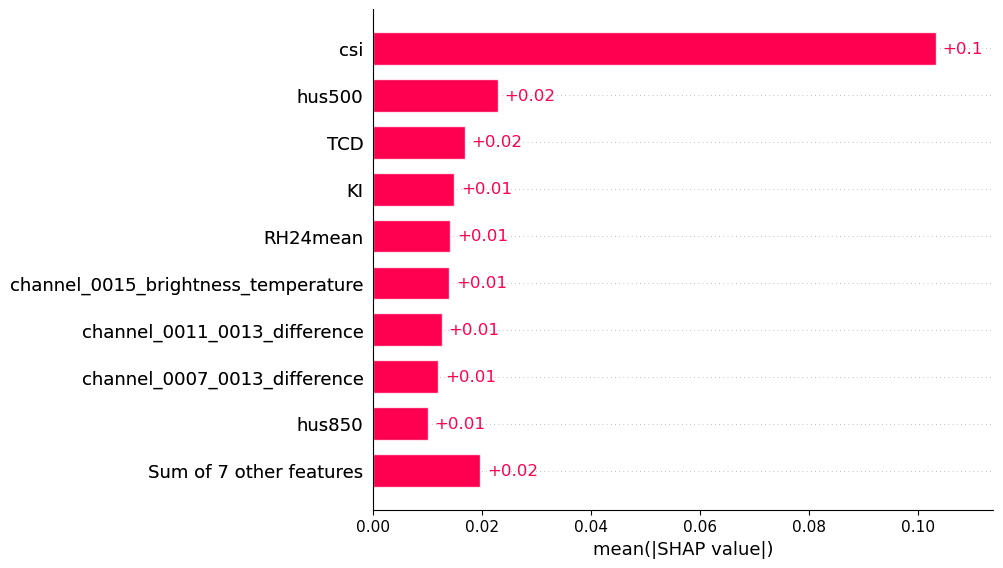

In [11]:
shap.plots.bar(shap_values)

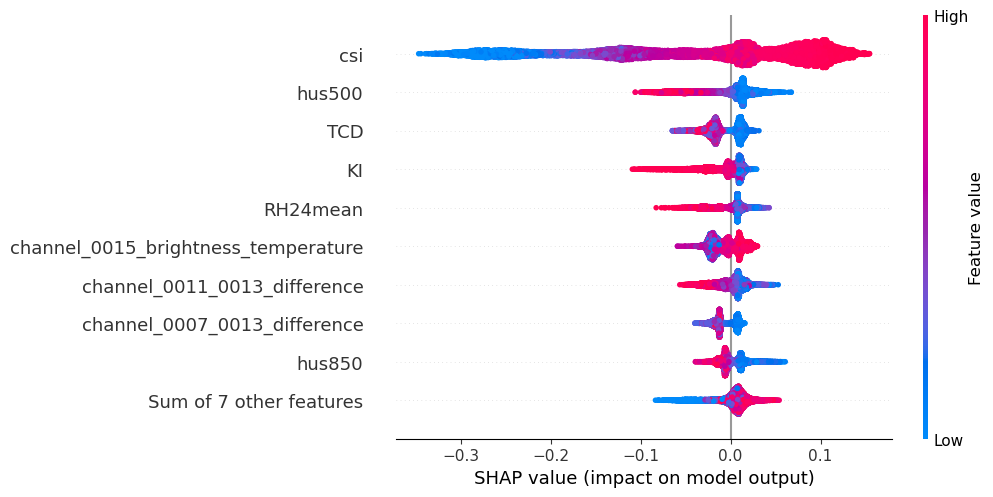

In [12]:
shap.plots.beeswarm(shap_values)